# Guarded IDBD: where it helps

A compact visual companion to `RESULTS.md`, using the saved experiment artifacts; no training is rerun.

- **Stationary sparse regression:** lower prediction MSE than all four tested optimizer selections, including classical IDBD.
- **Changing targets:** lower MSE than Adam and RMSprop, but worse than classical IDBD; the momentum comparison is inconclusive.
- **Trade-off:** improved accuracy in some settings, not faster computation or universal superiority.

One synthetic linear family, 20 features, 6,000 observations, 12 paired held-out seeds. Each method had 16 tuning configurations per regime. The stationary result is diagnostic, not the prespecified primary endpoint.

Requires Python, NumPy, Matplotlib, and a Jupyter Python kernel. Run from this repository or its `examples/` directory.

In [1]:
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents)
             if (p / "results/summary.json").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("Run this notebook from within the repository.")

def load(name):
    return json.loads((ROOT / "results" / name).read_text())

summary = load("summary.json")
evaluation = load("evaluation.json")
throughput = load("throughput.json")
methods = ["guarded", "idbd", "adam", "momentum", "rmsprop"]
labels = ["Guarded IDBD", "Classical IDBD", "Adam", "Momentum SGD", "RMSprop"]
colors = ["#13866b", "#3569ac", "#df8b30", "#9664a4", "#777777"]
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 10})
assert evaluation["complete"]
for regime in ("stationary", "tracking"):
    for method in methods:
        record = summary["summaries"][regime][method]
        assert record["seeds"] == 12 and record["failures"] == 0
print("Loaded saved results: 12 held-out seeds per method and regime.")

Loaded saved results: 12 held-out seeds per method and regime.


## 1. The clearest positive result: stationary accuracy

Guarded IDBD has the lowest mean MSE. Improvements relative to each comparator are calculated directly from the saved means. The dashed line is the observation-noise variance, not a measured optimizer result.

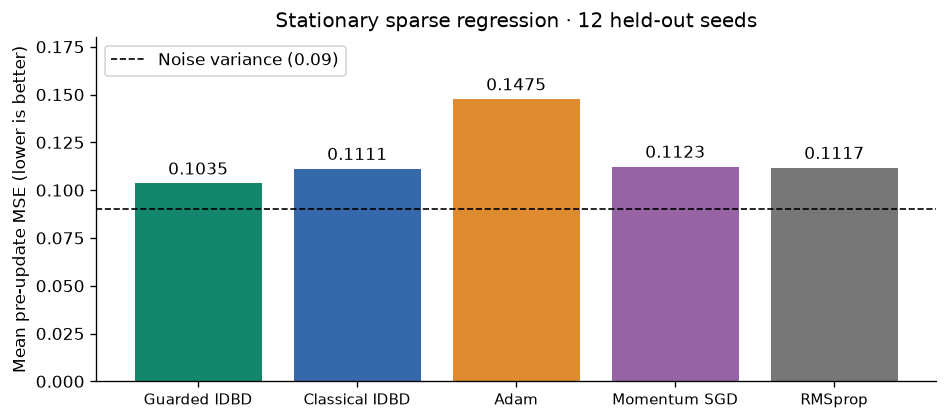

vs Classical IDBD: 6.9% lower MSE
vs Adam: 29.9% lower MSE
vs Momentum SGD: 7.8% lower MSE
vs RMSprop: 7.3% lower MSE


In [2]:
fig, ax = plt.subplots(figsize=(8, 3.6))
values = [summary["summaries"]["stationary"][m]["mean_mse"] for m in methods]
bars = ax.bar(labels, values, color=colors)
ax.bar_label(bars, fmt="%.4f", padding=3)
ax.axhline(0.09, color="black", linestyle="--", linewidth=1, label="Noise variance (0.09)")
ax.set(ylabel="Mean pre-update MSE (lower is better)", ylim=(0, max(values) * 1.22),
       title="Stationary sparse regression · 12 held-out seeds")
ax.tick_params(axis="x", labelsize=9)
ax.legend(loc="upper left")
fig.tight_layout()
plt.show()
for label, value in zip(labels[1:], values[1:]):
    print(f"vs {label}: {100 * (1 - values[0] / value):.1f}% lower MSE")

## 2. How certain are the accuracy comparisons?

Ratios below 1 favor guarded IDBD. Stationary intervals are **descriptive 95% paired-seed bootstrap intervals**. Tracking uses the saved **98.75% intervals for the four primary contrasts**. Intervals resample seeds, not time steps.

The stationary comparisons all favor guarded IDBD. On primary tracking, it beats Adam and RMSprop, loses to classical IDBD, and does not establish either a difference or equivalence with momentum SGD.

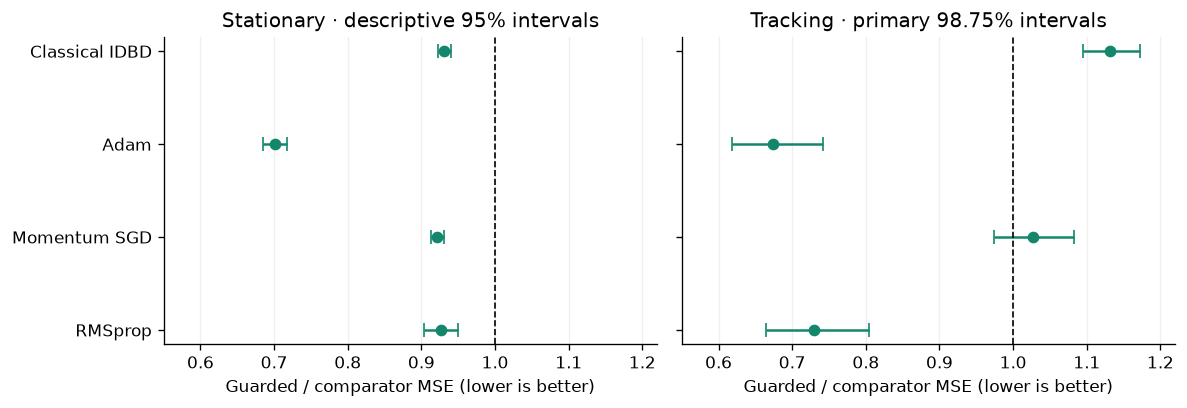

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), sharey=True)
for ax, regime, interval, title in zip(
    axes, ["stationary", "tracking"],
    ["ci95_ratio", "simultaneous_ci98_75_ratio"],
    ["Stationary · descriptive 95% intervals", "Tracking · primary 98.75% intervals"]
):
    records = [summary["comparisons"][regime][m]["mse"] for m in methods[1:]]
    ratios = np.array([r["ratio_of_means"] for r in records])
    bounds = np.array([r[interval] for r in records])
    ax.errorbar(ratios, np.arange(4),
                xerr=np.array([ratios - bounds[:, 0], bounds[:, 1] - ratios]),
                fmt="o", color=colors[0], capsize=4)
    ax.axvline(1, color="black", linestyle="--", linewidth=1)
    ax.set(yticks=np.arange(4), yticklabels=labels[1:], xlim=(0.55, 1.22),
           xlabel="Guarded / comparator MSE (lower is better)", title=title)
    ax.grid(axis="x", alpha=0.2)
axes[0].invert_yaxis()
fig.tight_layout()
plt.show()

## 3. Learning over time: the stationary gain persists

Each point averages a saved 500-observation block across 12 seeds. These are **nominal excess-risk curves**, excluding observation noise, not prediction MSE curves. The log scale makes late-stage differences visible; no uncertainty bands are implied. The post-startup comparison is exploratory, using the frozen runs.

Stationary risk after sample 500 — Guarded IDBD: 0.00476
Stationary risk after sample 500 — Classical IDBD: 0.01167
Stationary risk after sample 500 — Adam: 0.03651
Stationary risk after sample 500 — Momentum SGD: 0.01188
Stationary risk after sample 500 — RMSprop: 0.00666


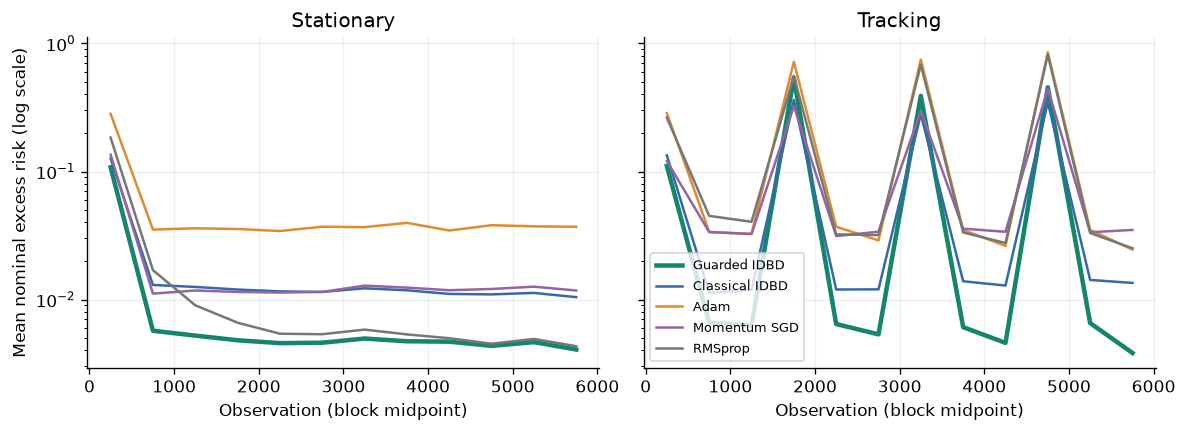

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.7), sharey=True)
for ax, regime in zip(axes, ["stationary", "tracking"]):
    for method, label, color in zip(methods, labels, colors):
        rows = [r for r in evaluation["rows"]
                if r["regime"] == regime and r["method"] == method]
        assert len(rows) == 12 and all(r["failure"] is None for r in rows)
        blocks = rows[0]["blocks"]
        assert all([(b["start"], b["stop"]) for b in r["blocks"]] ==
                   [(b["start"], b["stop"]) for b in blocks] for r in rows)
        x = [(b["start"] + b["stop"]) / 2 for b in blocks]
        risk = np.mean([[b["risk"] for b in r["blocks"]] for r in rows], axis=0)
        ax.plot(x, risk, label=label, color=color,
                linewidth=2.7 if method == "guarded" else 1.5)
        if regime == "stationary":
            weights = np.array([b["stop"] - b["start"] for b in blocks])
            keep = np.array([b["start"] >= 500 for b in blocks])
            print(f"Stationary risk after sample 500 — {label}: "
                  f"{np.average(risk[keep], weights=weights[keep]):.5f}")
    ax.set(yscale="log", xlabel="Observation (block midpoint)", title=regime.title())
    ax.grid(alpha=0.2)
axes[0].set_ylabel("Mean nominal excess risk (log scale)")
axes[1].legend(fontsize=8)
fig.tight_layout()
plt.show()

## 4. Accuracy is not throughput

This prototype is slower than all four comparators. These are CPU profiling measurements of the implemented core loop, not intrinsic algorithm complexity; they include prediction, analytical gradients, and optimizer validation.

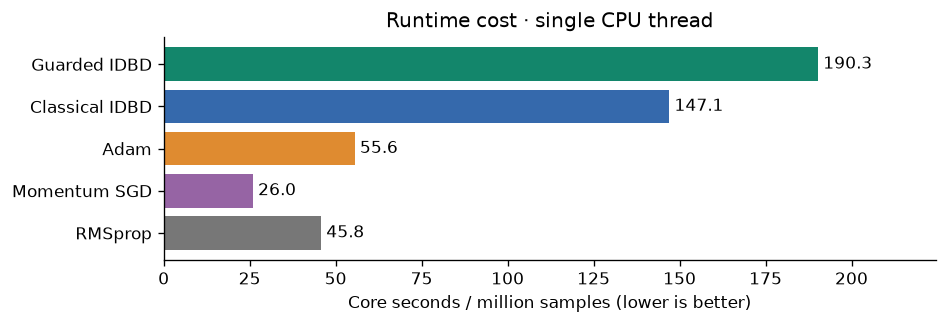

In [5]:
profile = {r["method"]: r for r in throughput["rows"]}
seconds = [profile[m]["core_seconds_per_million"] for m in methods]
fig, ax = plt.subplots(figsize=(8, 2.8))
bars = ax.barh(labels, seconds, color=colors)
ax.bar_label(bars, fmt="%.1f", padding=3)
ax.invert_yaxis()
ax.set(xlabel="Core seconds / million samples (lower is better)",
       xlim=(0, max(seconds) * 1.18), title="Runtime cost · single CPU thread")
fig.tight_layout()
plt.show()

## Takeaway and limits

**A real but narrow positive:** guarded IDBD wins this stationary sparse example against every tested selection, and beats Adam/RMSprop on the changing-target example. It does **not** beat classical IDBD on the primary tracking goal, and it is not faster.

The extreme-burst result is deliberately not presented as a win: classical IDBD's poor mean is dominated by one severe outlier, and its comparison interval crosses 1. The safeguard can also persistently depress learning rates after a burst.

Small finite tuning grids, boundary-selected hyperparameters, 12 evaluation seeds, and one synthetic diagonal linear family limit generalization. No full Autostep, schedules, correlated/rotated features, neural tasks, or GPU performance were tested. See `RESULTS.md` and `PROTOCOL.md` for the complete findings and experimental protocol.